# Phase 2c: Super-Resolution GAN (SRGAN) — BraTS 2025

Recovers high-frequency detail from low-resolution MRI.

- Input: 128×128 T1c (downsampled to 32×32 → bicubic-upsampled back)
- Loss: Perceptual (VGG) + adversarial + MSE
- Progressive: 32→64→128

In [1]:
import os,numpy as np,torch,torch.nn as nn,torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset,DataLoader
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# ══════════════ SR Paired Dataset ══════════════
PROC_DIR= r"C:\Users\Admin\processed_data"; MOD=1; SCALE=4
class SRDataset(Dataset):
    """Returns (low_res, high_res, masks)."""
    def __init__(s,split="train",mod=1,scale=4):
        s.sd=Path(PROC_DIR)/split/"slices";s.md=Path(PROC_DIR)/split/"masks"
        s.files=sorted(s.sd.glob("*.npy"));s.mod=mod;s.scale=scale
        print(f"  {split}: {len(s.files)} slices (SR scale={scale})")
    def __len__(s):return len(s.files)
    def __getitem__(s,i):
        f=s.files[i]
        hr=torch.from_numpy(np.load(str(f)).astype(np.float32)[s.mod:s.mod+1])  # (1,128,128)
        msk=torch.from_numpy(np.load(str(s.md/f.name)).astype(np.float32))      # (4,128,128)
        _,h,w=hr.shape
        small=F.interpolate(hr.unsqueeze(0),size=(h//s.scale,w//s.scale),mode="bilinear",align_corners=False)
        lr=F.interpolate(small,size=(h,w),mode="bicubic",align_corners=False).squeeze(0).clamp(0,1)
        return lr,hr,msk
train_ds=SRDataset("train",MOD,SCALE)
train_dl=DataLoader(train_ds,batch_size=64,shuffle=True,num_workers=0,pin_memory=True)

  train: 8382 slices (SR scale=4)


In [3]:
# ══════════════ Shared Blocks ══════════════
class DepthwiseSeparableConv2d(nn.Module):
    def __init__(s,i,o,k=3,st=1,p=1,b=False):super().__init__();s.dw=nn.Conv2d(i,i,k,st,p,groups=i,bias=b);s.pw=nn.Conv2d(i,o,1,bias=b)
    def forward(s,x):return s.pw(s.dw(x))
class DSConvBlock(nn.Module):
    def __init__(s,i,o,k=3,s_=1,act="leaky_relu",bn=True):
        super().__init__()
        layers=[DepthwiseSeparableConv2d(i,o,k,s_,k//2)]
        if bn:layers.append(nn.BatchNorm2d(o))
        a={"relu":nn.ReLU(True),"leaky_relu":nn.LeakyReLU(0.2,True),"prelu":nn.PReLU(o),"none":nn.Identity()}
        layers.append(a.get(act,nn.LeakyReLU(0.2,True)));s.block=nn.Sequential(*layers)
    def forward(s,x):return s.block(x)
class ResidualDSBlock(nn.Module):
    def __init__(s,ch):super().__init__();s.block=nn.Sequential(DSConvBlock(ch,ch),DSConvBlock(ch,ch,act="none"))
    def forward(s,x):return x+s.block(x)
def bce_loss(p,r):return F.binary_cross_entropy_with_logits(p,torch.ones_like(p) if r else torch.zeros_like(p))
class PSched:
    def __init__(s,lr=2e-4):s.stg=[{"r":32,"e":70,"ls":1.0},{"r":64,"e":38,"ls":0.5},{"r":128,"e":90,"ls":0.25}];s.lr0=lr;s.i=0
    @property
    def res(s):return s.stg[s.i]["r"]
    @property
    def ep(s):return s.stg[s.i]["e"]
    @property
    def lr(s):return s.lr0*s.stg[s.i]["ls"]
    @property
    def n(s):return len(s.stg)
    def adv(s):
        if s.i<len(s.stg)-1:s.i+=1;return True
        return False
    def rsz(s,x):r=s.res;return F.interpolate(x,size=(r,r),mode="bilinear",align_corners=False) if x.shape[-1]!=r else x
    def slr(s,*os):
        for o in os:
            for pg in o.param_groups:pg["lr"]=s.lr
    def __repr__(s):return f"S{s.i+1}/{len(s.stg)} r={s.res} lr={s.lr:.2e}"
print("✓ Ready")

✓ Ready


In [4]:
# ══════════════ SRGAN Architecture ══════════════
class SRGenerator(nn.Module):
    def __init__(s,bf=64,n_res=8):
        super().__init__()
        s.head=nn.Sequential(nn.Conv2d(1,bf,9,padding=4),nn.PReLU(bf))
        trunk=[ResidualDSBlock(bf) for _ in range(n_res)];trunk.append(DSConvBlock(bf,bf,act="none"))
        s.trunk=nn.Sequential(*trunk)
        s.tail=nn.Sequential(nn.Conv2d(bf,1,9,padding=4),nn.Sigmoid())
    def forward(s,x):h=s.head(x);return s.tail(h+s.trunk(h))

class SRDiscriminator(nn.Module):
    def __init__(s,bf=32):
        super().__init__()
        s.feat=nn.Sequential(nn.Conv2d(1,bf,3,padding=1),nn.LeakyReLU(0.2,True),
            DSConvBlock(bf,bf,k=3,s_=2),DSConvBlock(bf,bf*2),DSConvBlock(bf*2,bf*2,k=3,s_=2),
            DSConvBlock(bf*2,bf*4),DSConvBlock(bf*4,bf*4,k=3,s_=2),DSConvBlock(bf*4,bf*8),DSConvBlock(bf*8,bf*8,k=3,s_=2))
        s.cls=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Linear(bf*8,256),nn.LeakyReLU(0.2,True),nn.Linear(256,1))
    def forward(s,x):return s.cls(s.feat(x))

class PerceptualLoss(nn.Module):
    def __init__(s):
        super().__init__()
        vgg=models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        s.feat=nn.Sequential(*list(vgg.features.children())[:18])
        for p in s.feat.parameters():p.requires_grad=False
    def forward(s,pred,tgt):
        if pred.shape[1]==1:pred=pred.expand(-1,3,-1,-1);tgt=tgt.expand(-1,3,-1,-1)
        return F.mse_loss(s.feat(pred),s.feat(tgt))

G=SRGenerator(64,8).to(device);D=SRDiscriminator(32).to(device);perc=PerceptualLoss().to(device)
print(f"G:{sum(p.numel() for p in G.parameters()):,}  D:{sum(p.numel() for p in D.parameters()):,}")

G:92,097  D:204,609


In [5]:
SD = r"F:\shn\SRGAN"
os.makedirs(SD, exist_ok=True)

LR=2e-4; LP=0.006; LX=1.0
oG=torch.optim.Adam(G.parameters(),lr=LR,betas=(0.5,0.999))
oD=torch.optim.Adam(D.parameters(),lr=LR,betas=(0.5,0.999))
sc=PSched(LR); gl,dl=[],[]

# Fixed batch for consistent per-epoch visualization
_fix_iter = iter(train_dl)
_fix_lr, _fix_hr, _fix_masks = next(_fix_iter)
fixed_lr = _fix_lr[:5].to(device)
fixed_hr = _fix_hr[:5].to(device)

for stage in range(sc.n):
    print(f"\n{'='*50}\n  SRGAN | {sc}\n{'='*50}"); sc.slr(oG,oD)
    for ep in range(sc.ep):
        G.train(); D.train(); eg=ed=0.0
        for lr_img,hr_img,masks in tqdm(train_dl,desc=f"E{ep+1}/{sc.ep}",leave=False):
            lr_img=sc.rsz(lr_img.to(device)); hr_img=sc.rsz(hr_img.to(device))
            sr=G(lr_img).detach()
            lD=bce_loss(D(hr_img),True)+bce_loss(D(sr),False)
            oD.zero_grad();lD.backward();oD.step()
            sr=G(lr_img)
            lG=bce_loss(D(sr),True)+LP*perc(sr,hr_img)+LX*F.mse_loss(sr,hr_img)
            oG.zero_grad();lG.backward();oG.step()
            eg+=lG.item();ed+=lD.item()
        nb_=len(train_dl); gl.append(eg/nb_); dl.append(ed/nb_)

        # ── Per-epoch: create folder, save 5 images + weights ──
        epoch_dir = os.path.join(SD, f"stage{stage+1:02d}_epoch{ep+1:03d}")
        os.makedirs(epoch_dir, exist_ok=True)

        # Generate 5 SR samples from fixed LR inputs
        G.eval()
        with torch.no_grad():
            flr = sc.rsz(fixed_lr)
            generated = G(flr).cpu().numpy()  # (5,1,H,W)
            fhr = sc.rsz(fixed_hr).cpu().numpy()

        for i in range(5):
            fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
            axes[0].imshow(fhr[i, 0], cmap="gray"); axes[0].axis("off"); axes[0].set_title("HR (target)", fontsize=8)
            axes[1].imshow(generated[i, 0], cmap="gray"); axes[1].axis("off"); axes[1].set_title(f"SR Output\nG:{gl[-1]:.4f} D:{dl[-1]:.4f}", fontsize=8)
            plt.suptitle(f"S{stage+1} E{ep+1} Sample {i+1}", fontsize=9, fontweight="bold")
            plt.tight_layout()
            plt.savefig(os.path.join(epoch_dir, f"sample_{i+1:02d}.png"), dpi=100, bbox_inches="tight")
            plt.close()

        # Save weights inside this epoch folder
        torch.save({
            "G": G.state_dict(),
            "D": D.state_dict(),
            "epoch": ep + 1,
            "stage": stage + 1,
            "g_loss": gl[-1],
            "d_loss": dl[-1],
        }, os.path.join(epoch_dir, "weights.pt"))

        G.train()

        print(f"  Epoch {ep+1:3d}/{sc.ep} | G={gl[-1]:.4f} D={dl[-1]:.4f} | Saved → {epoch_dir}")

    sc.adv()

torch.save(G.state_dict(), f"{SD}/generator_final.pt")
torch.save(D.state_dict(), f"{SD}/discriminator_final.pt")
print("\n✓ SRGAN complete!")
print(f"✓ Per-epoch folders saved to: {SD}")



  SRGAN | S1/3 r=32 lr=2.00e-04


E1/70:   0%|          | 0/131 [00:00<?, ?it/s]

  Epoch   1/70 | G=0.7239 D=1.3800 | Saved → F:\shn\SRGAN\stage01_epoch001


E2/70:   0%|          | 0/131 [00:00<?, ?it/s]

  Epoch   2/70 | G=0.7150 D=1.3771 | Saved → F:\shn\SRGAN\stage01_epoch002


...

  Epoch  88/90 | G=4.0044 D=0.2048 | Saved → F:\shn\SRGAN\stage03_epoch088


E89/90:   0%|          | 0/131 [00:00<?, ?it/s]

  Epoch  89/90 | G=3.9975 D=0.2060 | Saved → F:\shn\SRGAN\stage03_epoch089


E90/90:   0%|          | 0/131 [00:00<?, ?it/s]

  Epoch  90/90 | G=3.9760 D=0.2088 | Saved → F:\shn\SRGAN\stage03_epoch090

✓ SRGAN complete!
✓ Per-epoch folders saved to: F:\shn\SRGAN



  TRAINING SUMMARY
Total Epochs Trained: 198
Total Iterations: 25938
Final Generator Loss:   3.976032
Final Discriminator Loss: 0.208781
Best Generator Loss:    0.715020 (Epoch 2)
Best Discriminator Loss: 0.182140 (Epoch 108)



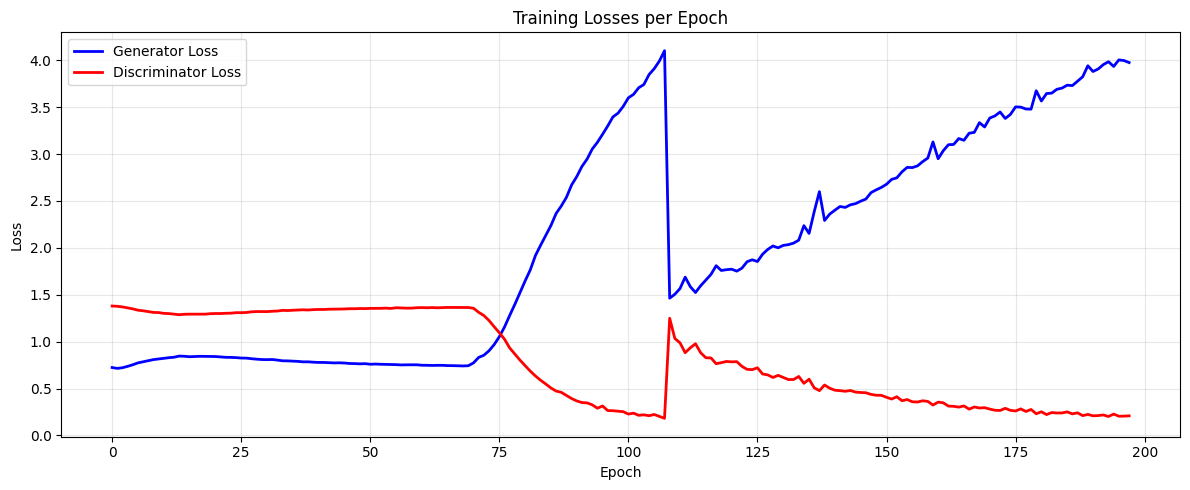

In [10]:
import matplotlib.pyplot as plt
import numpy as np


# ══════════════════ Visualization & Results ══════════════════
print("\n" + "="*70)
print("  TRAINING SUMMARY")
print("="*70)
# Use the actual accumulated per-epoch loss lists from training
g_losses = gl
d_losses = dl
iteration_counter = len(train_dl) * len(g_losses)
print(f"Total Epochs Trained: {len(g_losses)}")
print(f"Total Iterations: {iteration_counter}")
print(f"Final Generator Loss:   {g_losses[-1]:.6f}")
print(f"Final Discriminator Loss: {d_losses[-1]:.6f}")
print(f"Best Generator Loss:    {min(g_losses):.6f} (Epoch {np.argmin(g_losses)+1})")
print(f"Best Discriminator Loss: {min(d_losses):.6f} (Epoch {np.argmin(d_losses)+1})")
print("="*70 + "\n")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(g_losses, label="Generator Loss", linewidth=2, color="blue")
ax.plot(d_losses, label="Discriminator Loss", linewidth=2, color="red")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Losses per Epoch")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SD, "loss.png"), dpi=150)
plt.show()


  SRGAN COMPREHENSIVE EVALUATION

✓ Loaded generator from: F:\shn\SRGAN/generator_final.pt
  val: 1662 slices (SR scale=4)


Evaluating SRGAN:   0%|          | 0/104 [00:00<?, ?it/s]


  SRGAN EVALUATION SUMMARY  (48 samples)
  PSNR (↑ better)         : 21.6841 dB
  SSIM (↑ better)         : 0.688205
  MSE  (↓ better)         : 0.007148
  MAE  (↓ better)         : 0.043719
  LR→HR PSNR (baseline)   : 24.7900 dB
  SR Sharpness (↑ better) : 0.0218
  HR Sharpness (reference): 0.0200
  PSNR Improvement        : -3.1059 dB



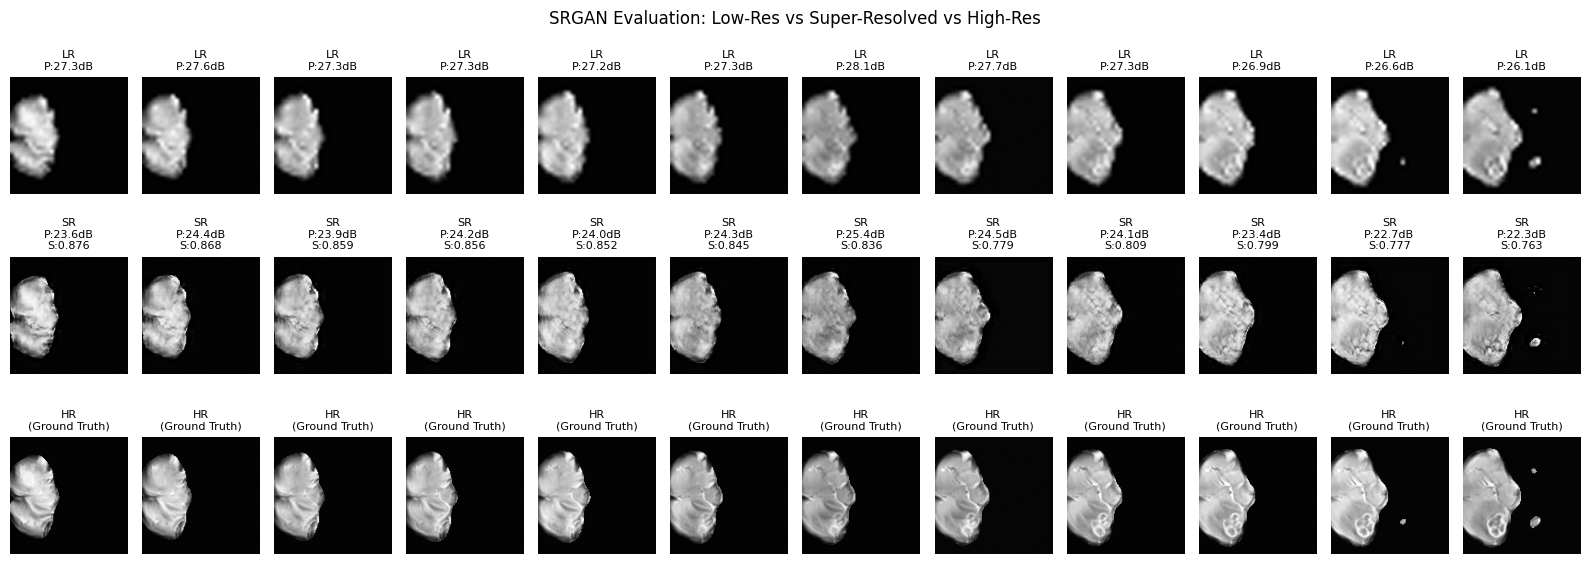

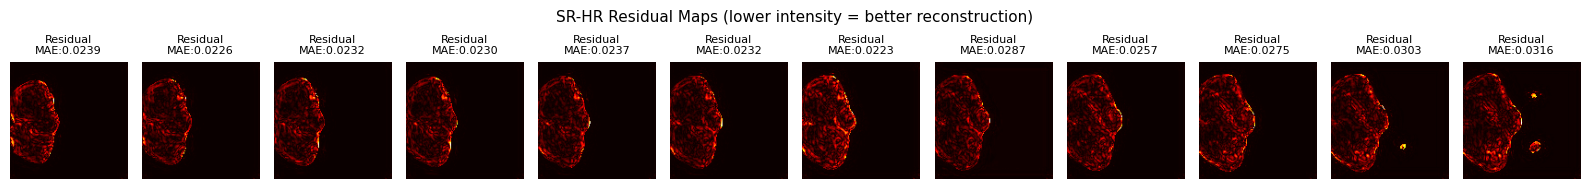

✓ Evaluation complete!
✓ Results saved to: F:\shn\SRGAN\test_outputs
  - comparison.png: Side-by-side LR/SR/HR visualizations
  - residuals.png: Error maps (SR - HR)
  - metrics.npy: Full metric dictionary


In [12]:
# ══════════════ COMPREHENSIVE TESTING & EVALUATION (SRGAN) ══════════════════
from skimage.metrics import structural_similarity as ssim_func
from skimage.metrics import peak_signal_noise_ratio as psnr_func

TEST_OUT = os.path.join(SD, "test_outputs")
os.makedirs(TEST_OUT, exist_ok=True)

print("\n" + "="*70)
print("  SRGAN COMPREHENSIVE EVALUATION")
print("="*70 + "\n")

# Load trained generator
G_test = SRGenerator(64, 8).to(device)
try:
    G_test.load_state_dict(torch.load(f"{SD}/generator_final.pt"))
    print(f"✓ Loaded generator from: {SD}/generator_final.pt")
except Exception as e:
    print(f"Warning: Failed to load generator weights: {e}")
G_test.eval()

# ── Metric Helper Functions for Super-Resolution ──
def compute_psnr(sr, hr):
    """Peak Signal-to-Noise Ratio (higher is better)."""
    sr_np = sr.clip(0, 1)
    hr_np = hr.clip(0, 1)
    mse = np.mean((sr_np - hr_np) ** 2)
    if mse == 0:
        return 100.0
    max_val = 1.0
    psnr = 20 * np.log10(max_val / np.sqrt(mse))
    return float(psnr)

def compute_ssim(sr, hr):
    """Structural Similarity Index (higher is better)."""
    sr_np = sr.clip(0, 1)
    hr_np = hr.clip(0, 1)
    data_range = 1.0
    try:
        return float(ssim_func(sr_np, hr_np, data_range=data_range))
    except:
        return np.nan

def compute_mse(sr, hr):
    """Mean Squared Error (lower is better)."""
    sr_np = sr.clip(0, 1)
    hr_np = hr.clip(0, 1)
    return float(np.mean((sr_np - hr_np) ** 2))

def compute_mae(sr, hr):
    """Mean Absolute Error (lower is better)."""
    sr_np = sr.clip(0, 1)
    hr_np = hr.clip(0, 1)
    return float(np.mean(np.abs(sr_np - hr_np)))

def compute_sharpness(img):
    """Estimate sharpness using Laplacian variance (higher is better)."""
    from scipy.ndimage import laplace
    try:
        laplacian = laplace(img)
        return float(np.var(laplacian))
    except:
        return np.nan

# ── Test Dataloader ──
val_ds = SRDataset("val", MOD, SCALE)
val_dl = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# ── Evaluation Loop ──
metrics = {
    "psnr": [], "ssim": [], "mse": [], "mae": [], 
    "lr_psnr": [], "sr_sharpness": [], "hr_sharpness": []
}
all_lr, all_sr, all_hr, all_masks = [], [], [], []
count = 0

with torch.no_grad():
    for batch_idx, (lr, hr, masks) in enumerate(tqdm(val_dl, desc="Evaluating SRGAN", leave=True)):
        lr_t = sc.rsz(lr.to(device))
        hr_t = sc.rsz(hr.to(device))
        
        # Super-resolve
        sr_t = G_test(lr_t)

        lr_np = lr_t.cpu().numpy()
        sr_np = sr_t.cpu().numpy()
        hr_np = hr_t.cpu().numpy()
        masks_np = masks.numpy()

        for i in range(lr_np.shape[0]):
            lr_img = lr_np[i, 0]
            sr_img = sr_np[i, 0]
            hr_img = hr_np[i, 0]
            mask = masks_np[i]

            # Compute metrics
            metrics["psnr"].append(compute_psnr(sr_img, hr_img))
            metrics["ssim"].append(compute_ssim(sr_img, hr_img))
            metrics["mse"].append(compute_mse(sr_img, hr_img))
            metrics["mae"].append(compute_mae(sr_img, hr_img))
            metrics["lr_psnr"].append(compute_psnr(lr_img, hr_img))
            metrics["sr_sharpness"].append(compute_sharpness(sr_img))
            metrics["hr_sharpness"].append(compute_sharpness(hr_img))

            # Store for visualization
            all_lr.append(lr_img)
            all_sr.append(sr_img)
            all_hr.append(hr_img)
            all_masks.append(mask)
            count += 1

        if count >= 48:  # Evaluate on ~48 samples
            break

# ── Summary Statistics ──
def safe_mean(lst):
    vals = [v for v in lst if not np.isnan(v)]
    return np.mean(vals) if vals else np.nan

print(f"\n{'='*70}")
print(f"  SRGAN EVALUATION SUMMARY  ({count} samples)")
print(f"{'='*70}")
print(f"  PSNR (↑ better)         : {safe_mean(metrics['psnr']):.4f} dB")
print(f"  SSIM (↑ better)         : {safe_mean(metrics['ssim']):.6f}")
print(f"  MSE  (↓ better)         : {safe_mean(metrics['mse']):.6f}")
print(f"  MAE  (↓ better)         : {safe_mean(metrics['mae']):.6f}")
print(f"  LR→HR PSNR (baseline)   : {safe_mean(metrics['lr_psnr']):.4f} dB")
print(f"  SR Sharpness (↑ better) : {safe_mean(metrics['sr_sharpness']):.4f}")
print(f"  HR Sharpness (reference): {safe_mean(metrics['hr_sharpness']):.4f}")
improvement_psnr = safe_mean(metrics['psnr']) - safe_mean(metrics['lr_psnr'])
print(f"  PSNR Improvement        : {improvement_psnr:+.4f} dB")
print(f"{'='*70}\n")

# ── Visualization: LR vs SR vs HR ──
n_show = min(12, count)
fig, axes = plt.subplots(3, n_show, figsize=(16, 6))
for i in range(n_show):
    axes[0, i].imshow(all_lr[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"LR\nP:{metrics['lr_psnr'][i]:.1f}dB", fontsize=8)
    axes[0, i].axis("off")
    
    axes[1, i].imshow(all_sr[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"SR\nP:{metrics['psnr'][i]:.1f}dB\nS:{metrics['ssim'][i]:.3f}", fontsize=8)
    axes[1, i].axis("off")
    
    axes[2, i].imshow(all_hr[i], cmap="gray", vmin=0, vmax=1)
    axes[2, i].set_title(f"HR\n(Ground Truth)", fontsize=8)
    axes[2, i].axis("off")

fig.suptitle("SRGAN Evaluation: Low-Res vs Super-Resolved vs High-Res", fontsize=12, y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(TEST_OUT, "comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Residual visualization (SR vs HR) ──
fig, axes = plt.subplots(1, n_show, figsize=(16, 2))
for i in range(n_show):
    residual = np.abs(all_sr[i] - all_hr[i])
    im = axes[i].imshow(residual, cmap="hot")
    axes[i].set_title(f"Residual\nMAE:{metrics['mae'][i]:.4f}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("SR-HR Residual Maps (lower intensity = better reconstruction)", fontsize=11, y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(TEST_OUT, "residuals.png"), dpi=150, bbox_inches="tight")
plt.show()

# Save metrics to file
np.save(os.path.join(TEST_OUT, "metrics.npy"), metrics)
print(f"✓ Evaluation complete!")
print(f"✓ Results saved to: {TEST_OUT}")
print(f"  - comparison.png: Side-by-side LR/SR/HR visualizations")
print(f"  - residuals.png: Error maps (SR - HR)")
print(f"  - metrics.npy: Full metric dictionary")
